In [1]:
#Homework 8
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [2]:
import numpy as np
import tensorflow as tf

print(np.__version__)
print(tf.__version__)

1.23.5
2.10.0


In [3]:
# Q1 Data generation
N_sin = 10000
N_sample = 100
np.random.seed(42)

t = np.linspace(0, 4 * np.pi, N_sample)  
A = np.random.uniform(0.5, 1.5, size=(N_sin, 1))      
omega = np.random.uniform(0.5, 2.0, size=(N_sin, 1))  
phi = np.random.uniform(0, 2 * np.pi, size=(N_sin, 1))

clean_curve = A * np.sin(omega * t + phi)

# Add Gaussian noise (sigma = 0.2)
sigma = 0.2
noise = np.random.normal(0, sigma, size=(N_sin, N_sample))

noisy_curve = clean_curve + noise

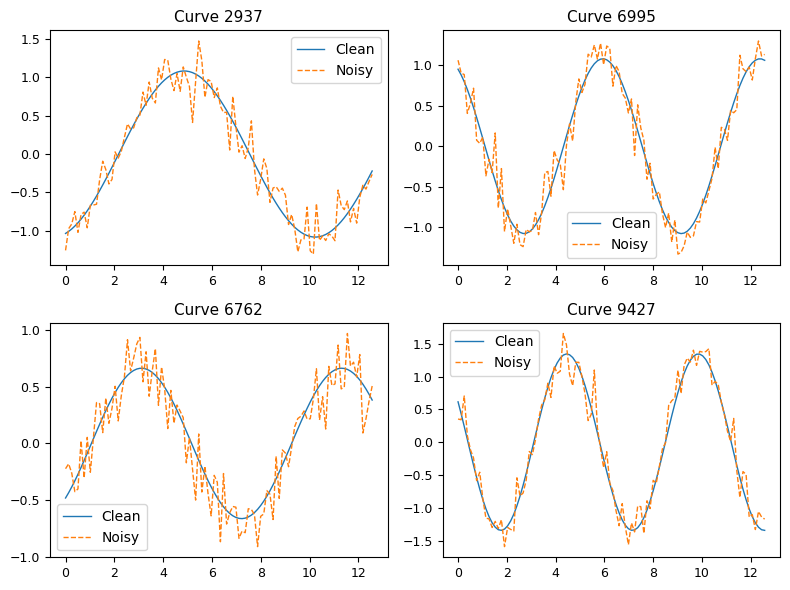

In [7]:
# Plot 4 examples
indices = np.random.choice(N_sin, 4, replace=False)

plt.figure(figsize=(8, 6))

for i, idx in enumerate(indices):
    plt.subplot(2, 2, i+1)
    plt.plot(t, clean_curve[idx], label="Clean", lw=1)
    plt.plot(t, noisy_curve[idx], label="Noisy", lw=1, linestyle="--")
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.title(f"Curve {idx}", fontsize=11)
    plt.legend(loc='best')

plt.tight_layout()
#plt.show()

In [8]:
num_curves = noisy_curve.shape[0]

# Create shuffled indices
indices = np.random.permutation(num_curves)

# Split index
split = int(0.9 * num_curves)

train_idx = indices[:split]
val_idx = indices[split:]

# Create splits
x_train = noisy_curve[train_idx]
y_train = clean_curve[train_idx]

x_val = noisy_curve[val_idx]
y_val = clean_curve[val_idx]

# Verify shapes
print(x_train.shape, y_train.shape)  # (9000, 100)
print(x_val.shape, y_val.shape)      # (1000, 100)

(9000, 100) (9000, 100)
(1000, 100) (1000, 100)


In [9]:
# Q2 Autoencoder Model
N = 100

autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                6464      
                                                                 
 dense_1 (Dense)             (None, 16)                1040      
                                                                 
 dense_2 (Dense)             (None, 64)                1088      
                                                                 
 dense_3 (Dense)             (None, 100)               6500      
                                                                 
Total params: 15,092
Trainable params: 15,092
Non-trainable params: 0
_________________________________________________________________


In [10]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 [==============================] - 1s 6ms/step - loss: 0.3531 - val_loss: 0.1217
Epoch 2/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0667 - val_loss: 0.0409
Epoch 3/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0293 - val_loss: 0.0203
Epoch 4/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0168 - val_loss: 0.0154
Epoch 5/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0137 - val_loss: 0.0129
Epoch 6/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 7/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0097 - val_loss: 0.0093
Epoch 8/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0082 - val_loss: 0.0080
Epoch 9/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0072 - val_loss: 0.0074
Epoch 10/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0066 - val_loss: 0.0067
Epoch 11/50
71/71 [

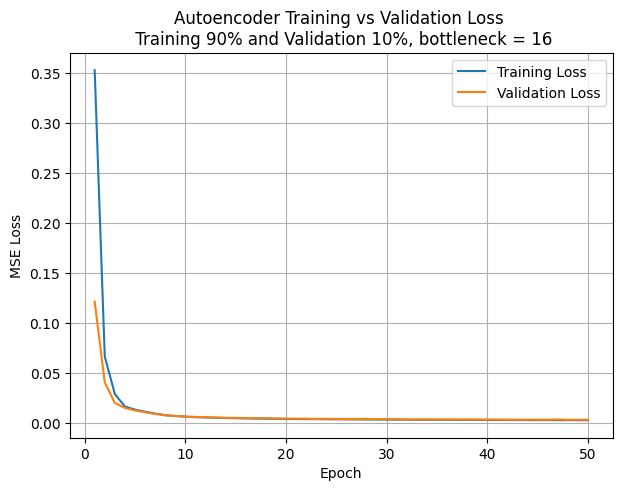

In [29]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss \n Training 90% and Validation 10%, bottleneck = 16")
plt.legend()
plt.grid(True)

32/32 [==============================] - 0s 2ms/step


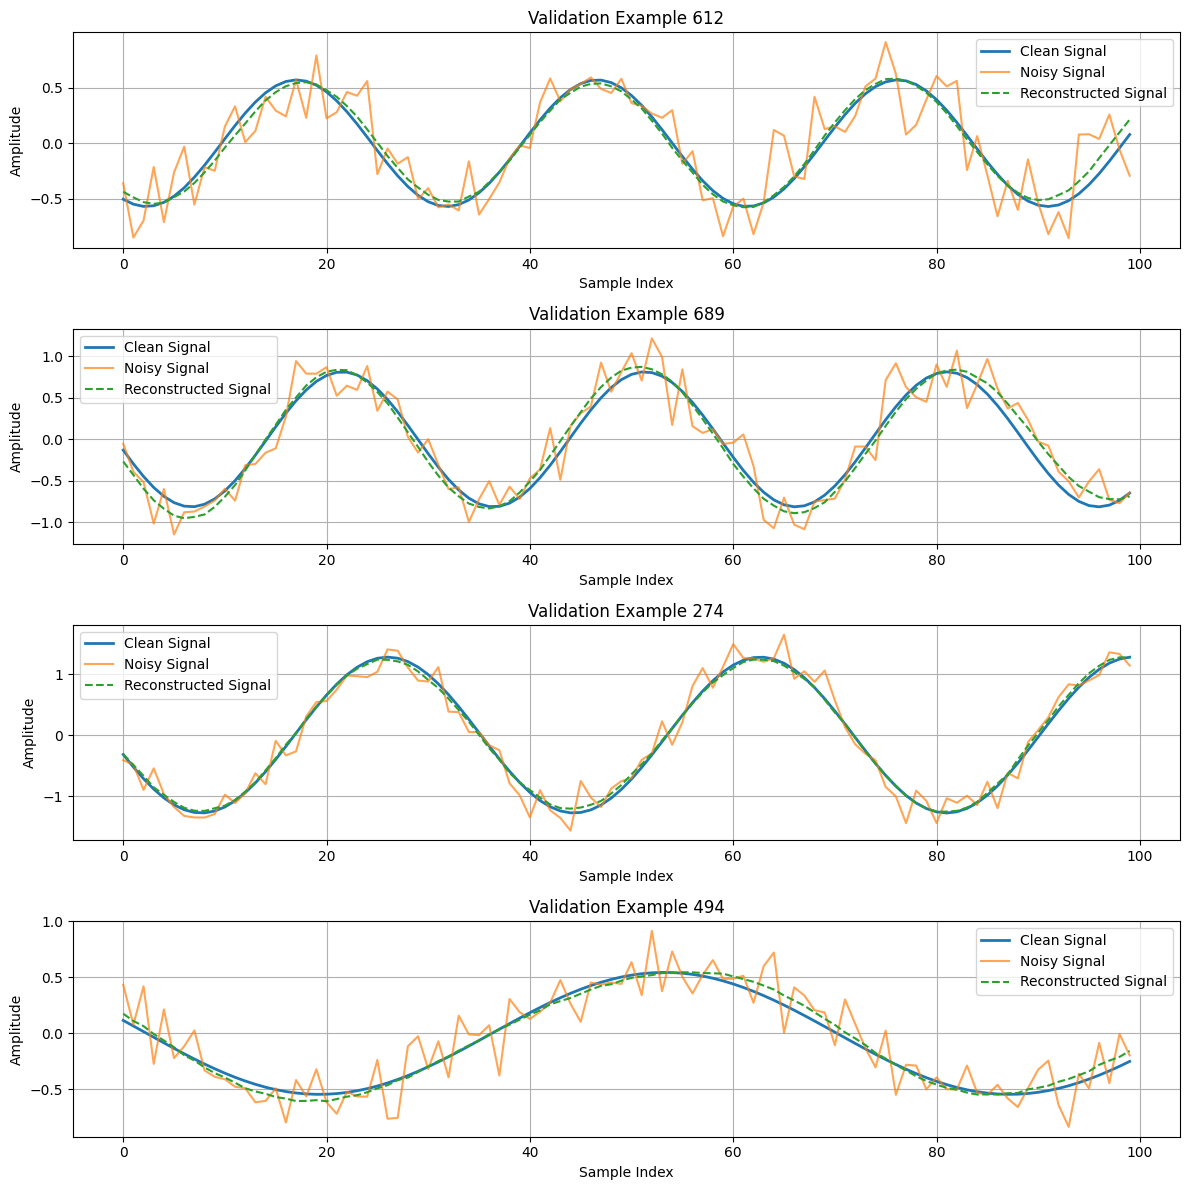

In [13]:
# 2. Plot clean / noisy / reconstructed signals

# Reconstruct validation signals
y_pred = autoencoder.predict(x_val)
#reconstructed_Y = autoencoder.predict(x_val)

# Number of examples to display
num_examples = 4

# Random validation examples
example_idx = np.random.choice(len(x_val), num_examples, replace=False)

fig, axes = plt.subplots(num_examples, 1, figsize=(12, 3*num_examples))

# Handle case where num_examples = 1
if num_examples == 1:
    axes = [axes]

for i, idx in enumerate(example_idx):

    axes[i].plot(y_val[idx], label='Clean Signal', linewidth=2)
    axes[i].plot(x_val[idx], label='Noisy Signal', alpha=0.7)
    axes[i].plot(y_pred[idx], label='Reconstructed Signal', linestyle='--')

    axes[i].set_title(f'Validation Example {idx}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()

In [15]:
# Q3 Parameter Explorartion
num_curves = noisy_curve.shape[0]

# Create shuffled indices
indices = np.random.permutation(num_curves)

# Split index 60% training , 40% validation
split2 = int(0.6 * num_curves)

train_idx2 = indices[:split2]
val_idx2 = indices[split2:]

# Create splits
x_train2 = noisy_curve[train_idx2]
y_train2 = clean_curve[train_idx2]

x_val2 = noisy_curve[val_idx2]
y_val2 = clean_curve[val_idx2]

# Verify shapes
print(x_train2.shape, y_train2.shape)  # (6000, 100)
print(x_val2.shape, y_val2.shape)      # (4000, 100)

# Model 2 : 100 → 80 → 40 → 4 → 40 → 80 → 100
# Bottleneck at 4
N = 100
autoencoder2 = Sequential([
    Input(shape=(N,)),
    Dense(80, activation='relu'),
    Dense(40, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(40, activation='relu'),
    Dense(80, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder2.compile(optimizer=Adam(0.001), loss='mse')
autoencoder2.summary()

(6000, 100) (6000, 100)
(4000, 100) (4000, 100)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 80)                8080      
                                                                 
 dense_11 (Dense)            (None, 40)                3240      
                                                                 
 dense_12 (Dense)            (None, 4)                 164       
                                                                 
 dense_13 (Dense)            (None, 40)                200       
                                                                 
 dense_14 (Dense)            (None, 80)                3280      
                                                                 
 dense_15 (Dense)            (None, 100)               8100      
                                                                 
Total 

In [16]:
history2 = autoencoder2.fit(
    x_train2, y_train2,
    epochs=50,
    batch_size=128,
    validation_data=(x_val2, y_val2),
    verbose=1
)

# extract loss values for plotting
train_loss2   = history2.history['loss'] # training loss per epoch
val_loss2     = history2.history['val_loss'] # validation loss per epoch
epochs_range2 = range(1, len(train_loss2) + 1)

Epoch 1/50
47/47 [==============================] - 1s 8ms/step - loss: 0.4853 - val_loss: 0.4056
Epoch 2/50
47/47 [==============================] - 0s 6ms/step - loss: 0.3104 - val_loss: 0.2349
Epoch 3/50
47/47 [==============================] - 0s 5ms/step - loss: 0.2083 - val_loss: 0.1864
Epoch 4/50
47/47 [==============================] - 0s 6ms/step - loss: 0.1643 - val_loss: 0.1433
Epoch 5/50
47/47 [==============================] - 0s 6ms/step - loss: 0.1193 - val_loss: 0.1010
Epoch 6/50
47/47 [==============================] - 0s 6ms/step - loss: 0.0876 - val_loss: 0.0822
Epoch 7/50
47/47 [==============================] - 0s 6ms/step - loss: 0.0721 - val_loss: 0.0679
Epoch 8/50
47/47 [==============================] - 0s 6ms/step - loss: 0.0621 - val_loss: 0.0608
Epoch 9/50
47/47 [==============================] - 0s 6ms/step - loss: 0.0556 - val_loss: 0.0561
Epoch 10/50
47/47 [==============================] - 0s 5ms/step - loss: 0.0497 - val_loss: 0.0487
Epoch 11/50
47/47 [

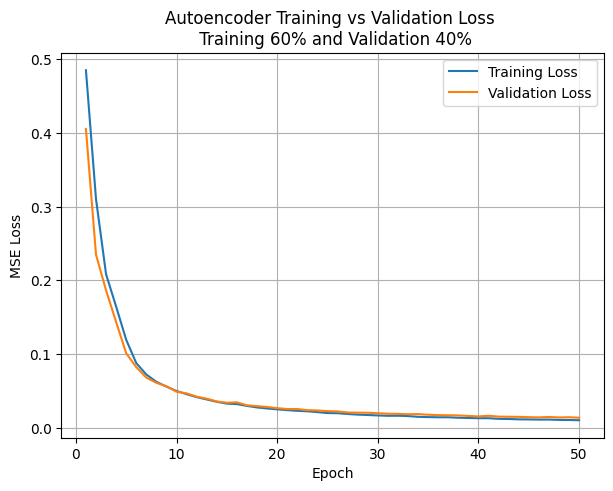

In [20]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range2, train_loss2, label="Training Loss")
plt.plot(epochs_range2, val_loss2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss \n Training 60% and Validation 40%")
plt.legend()
plt.grid(True)

In [18]:
num_curves = noisy_curve.shape[0]

# Create shuffled indices
indices = np.random.permutation(num_curves)

# Split index 30% training , 70% validation
split3 = int(0.3 * num_curves)

train_idx3 = indices[:split3]
val_idx3 = indices[split3:]

# Create splits
x_train3 = noisy_curve[train_idx3]
y_train3 = clean_curve[train_idx3]

x_val3 = noisy_curve[val_idx3]
y_val3 = clean_curve[val_idx3]

# Verify shapes
print(x_train3.shape, y_train3.shape)  # (6000, 100)
print(x_val3.shape, y_val3.shape)      # (4000, 100)

# 100 → 64 → 32 → 16 → 4 → 16 → 32 → 64 → 100
# Bottleneck at 4
N = 100
autoencoder3 = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder3.compile(optimizer=Adam(0.001), loss='mse')
autoencoder3.summary()

(3000, 100) (3000, 100)
(7000, 100) (7000, 100)
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 64)                6464      
                                                                 
 dense_17 (Dense)            (None, 32)                2080      
                                                                 
 dense_18 (Dense)            (None, 16)                528       
                                                                 
 dense_19 (Dense)            (None, 4)                 68        
                                                                 
 dense_20 (Dense)            (None, 16)                80        
                                                                 
 dense_21 (Dense)            (None, 32)                544       
                                                                 
 dense

In [19]:
history3 = autoencoder3.fit(
    x_train3, y_train3,
    epochs=50,
    batch_size=128,
    validation_data=(x_val3, y_val3),
    verbose=1
)

# extract loss values for plotting
train_loss3   = history3.history['loss'] # training loss per epoch
val_loss3     = history3.history['val_loss'] # validation loss per epoch
epochs_range3 = range(1, len(train_loss3) + 1)

Epoch 1/50
24/24 [==============================] - 1s 17ms/step - loss: 0.5229 - val_loss: 0.5023
Epoch 2/50
24/24 [==============================] - 0s 9ms/step - loss: 0.4702 - val_loss: 0.4327
Epoch 3/50
24/24 [==============================] - 0s 9ms/step - loss: 0.3945 - val_loss: 0.3560
Epoch 4/50
24/24 [==============================] - 0s 9ms/step - loss: 0.3199 - val_loss: 0.2957
Epoch 5/50
24/24 [==============================] - 0s 9ms/step - loss: 0.2671 - val_loss: 0.2441
Epoch 6/50
24/24 [==============================] - 0s 9ms/step - loss: 0.2179 - val_loss: 0.2029
Epoch 7/50
24/24 [==============================] - 0s 10ms/step - loss: 0.1877 - val_loss: 0.1815
Epoch 8/50
24/24 [==============================] - 0s 11ms/step - loss: 0.1677 - val_loss: 0.1649
Epoch 9/50
24/24 [==============================] - 0s 12ms/step - loss: 0.1517 - val_loss: 0.1478
Epoch 10/50
24/24 [==============================] - 0s 10ms/step - loss: 0.1366 - val_loss: 0.1354
Epoch 11/50
24

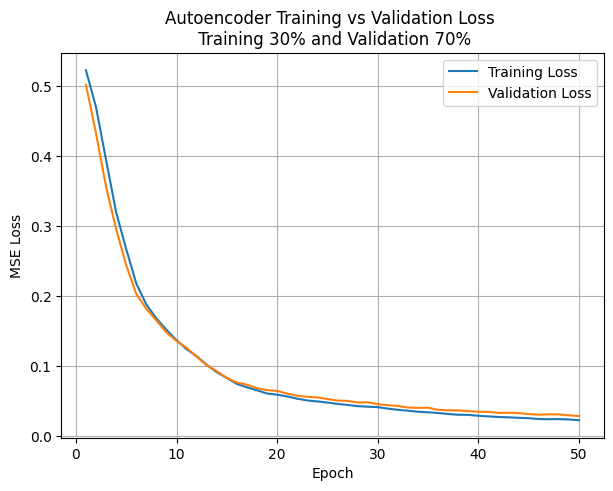

In [22]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range3, train_loss3, label="Training Loss")
plt.plot(epochs_range3, val_loss3, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss \n Training 30% and Validation 70%")
plt.legend()
plt.grid(True)

In [56]:
# Varying the bottle neck 16, 8, 4, 3, 2, 1.

num_curves = noisy_curve.shape[0]

# Create shuffled indices
indices = np.random.permutation(num_curves)

# Split index
split4 = int(0.9 * num_curves)

train_idx4 = indices[:split4]
val_idx4 = indices[split4:]

# Create splits
x_train4 = noisy_curve[train_idx4]
y_train4 = clean_curve[train_idx4]

x_val4 = noisy_curve[val_idx4]
y_val4 = clean_curve[val_idx4]

# Verify shapes
print(x_train4.shape, y_train4.shape)  # (9000, 100)
print(x_val4.shape, y_val4.shape)      # (1000, 100)

N = 100
bottleneck = 1
autoencoder4 = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(bottleneck, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder4.compile(optimizer=Adam(0.001), loss='mse')
autoencoder4.summary()

(9000, 100) (9000, 100)
(1000, 100) (1000, 100)
Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_64 (Dense)            (None, 64)                6464      
                                                                 
 dense_65 (Dense)            (None, 1)                 65        
                                                                 
 dense_66 (Dense)            (None, 64)                128       
                                                                 
 dense_67 (Dense)            (None, 100)               6500      
                                                                 
Total params: 13,157
Trainable params: 13,157
Non-trainable params: 0
_________________________________________________________________


In [57]:
history4 = autoencoder4.fit(
    x_train4, y_train4,
    epochs=50,
    batch_size=128,
    validation_data=(x_val4, y_val4),
    verbose=1
)

# extract loss values for plotting
train_loss4   = history4.history['loss'] # training loss per epoch
val_loss4     = history4.history['val_loss'] # validation loss per epoch
epochs_range4 = range(1, len(train_loss4) + 1)

Epoch 1/50
71/71 [==============================] - 1s 6ms/step - loss: 0.5083 - val_loss: 0.4897
Epoch 2/50
71/71 [==============================] - 0s 3ms/step - loss: 0.4804 - val_loss: 0.4809
Epoch 3/50
71/71 [==============================] - 0s 4ms/step - loss: 0.4725 - val_loss: 0.4746
Epoch 4/50
71/71 [==============================] - 0s 4ms/step - loss: 0.4659 - val_loss: 0.4683
Epoch 5/50
71/71 [==============================] - 0s 4ms/step - loss: 0.4592 - val_loss: 0.4609
Epoch 6/50
71/71 [==============================] - 0s 3ms/step - loss: 0.4517 - val_loss: 0.4536
Epoch 7/50
71/71 [==============================] - 0s 4ms/step - loss: 0.4456 - val_loss: 0.4495
Epoch 8/50
71/71 [==============================] - 0s 4ms/step - loss: 0.4409 - val_loss: 0.4438
Epoch 9/50
71/71 [==============================] - 0s 4ms/step - loss: 0.4377 - val_loss: 0.4408
Epoch 10/50
71/71 [==============================] - 0s 4ms/step - loss: 0.4366 - val_loss: 0.4404
Epoch 11/50
71/71 [

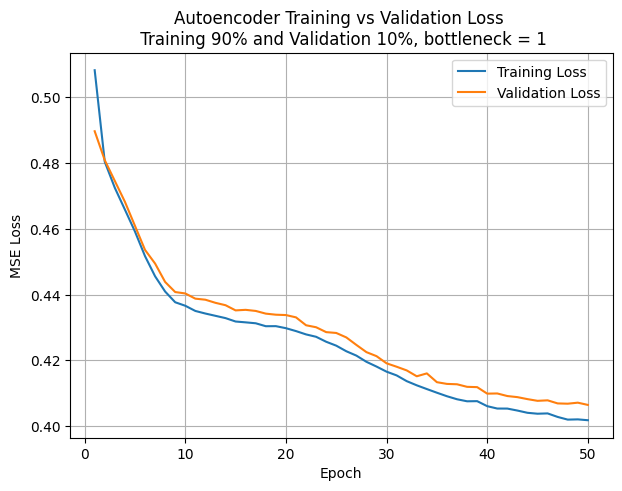

In [58]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range4, train_loss4, label="Training Loss")
plt.plot(epochs_range4, val_loss4, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"Autoencoder Training vs Validation Loss \n Training 90% and Validation 10%, bottleneck = {bottleneck}")
plt.legend()
plt.grid(True)

32/32 [==============================] - 0s 3ms/step


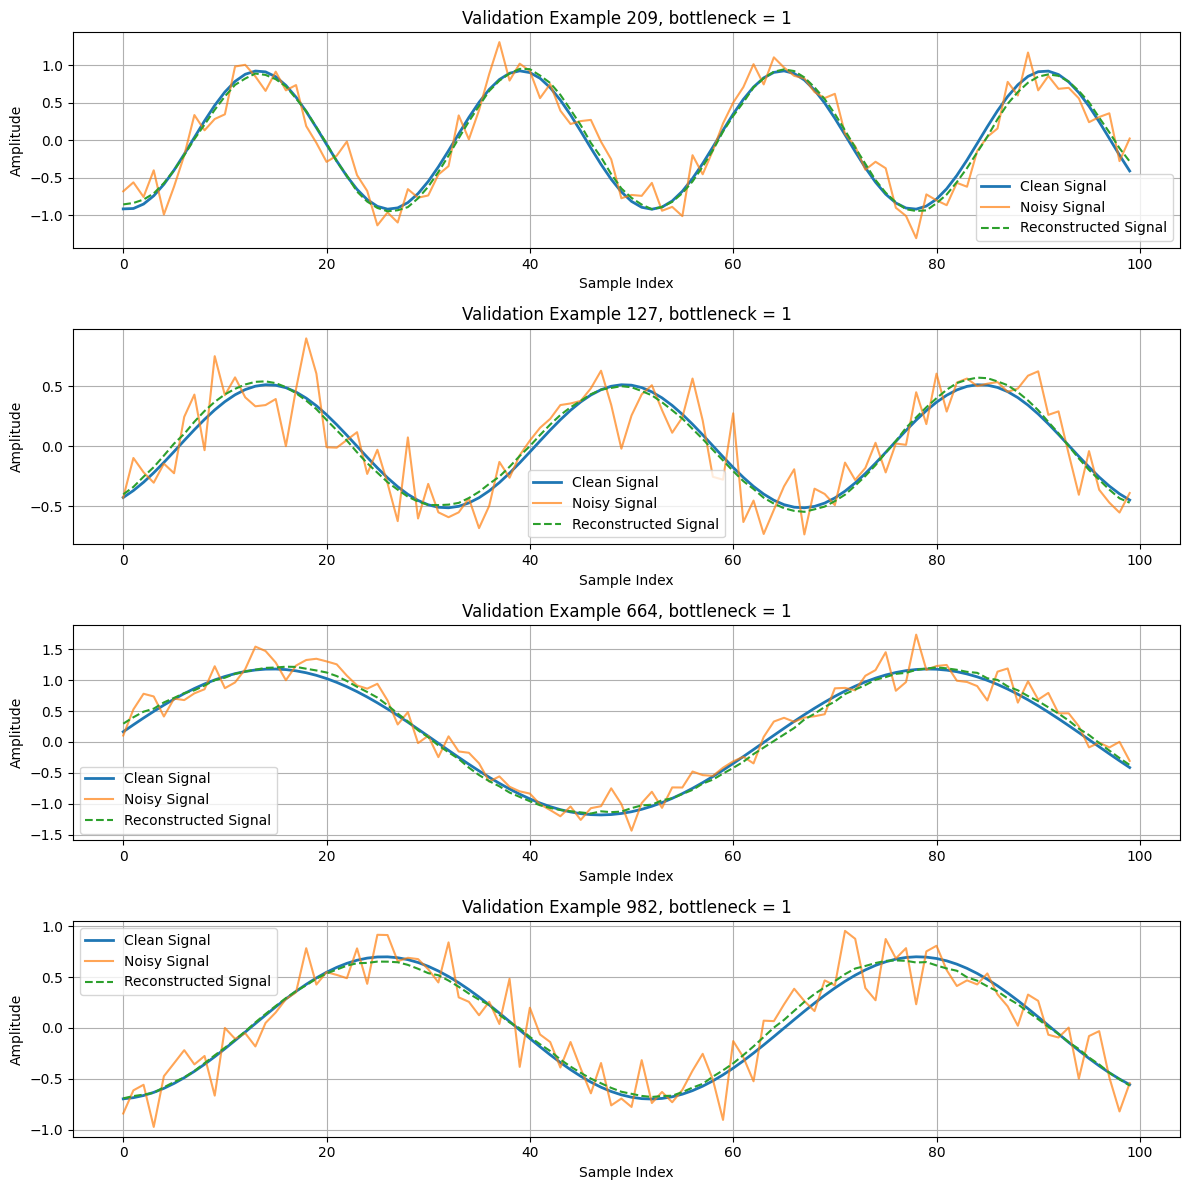

In [59]:
# Plot clean / noisy / reconstructed signals

# Reconstruct validation signals
y_pred4 = autoencoder.predict(x_val4)
#reconstructed_Y = autoencoder.predict(x_val)

# Number of examples to display
num_examples = 4

# Random validation examples
example_idx4 = np.random.choice(len(x_val4), num_examples, replace=False)

fig, axes = plt.subplots(num_examples, 1, figsize=(12, 3*num_examples))

# Handle case where num_examples = 1
if num_examples == 1:
    axes = [axes]

for i, idx in enumerate(example_idx4):

    axes[i].plot(y_val4[idx], label='Clean Signal', linewidth=2)
    axes[i].plot(x_val4[idx], label='Noisy Signal', alpha=0.7)
    axes[i].plot(y_pred4[idx], label='Reconstructed Signal', linestyle='--')

    axes[i].set_title(f'Validation Example {idx}, bottleneck = {bottleneck}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()